### **Business Problem:**

Delhivery is the largest and fastest-growing fully integrated player in India by revenue in Fiscal 2021. They aim to build the operating system for commerce, through a combination of world-class infrastructure, logistics operations of the highest quality, and cutting-edge engineering and technology capabilities.
The Data team builds intelligence and capabilities using this data that helps them to widen the gap between the quality, efficiency, and profitability of their business versus their competitors.

The company wants to understand and process the data coming out of data engineering pipelines:

- Clean, sanitize and manipulate data to get useful features out of raw fields
- Make sense out of the raw data and help the data science team to build forecasting models on it

In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import re
from scipy.stats import ttest_rel

In [58]:
df_dhy = pd.read_csv('C:\\Users\\njain121\\Desktop\\Scalar\\CaseStudy\\Delhivery\\delhivery_data.csv')
df_dhy.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


### Column Profiling: ###

- data - tells whether the data is testing or training data
- trip_creation_time – Timestamp of trip creation
- route_schedule_uuid – Unique Id for a particular route schedule
- route_type – Transportation type
- FTL – Full Truck Load: FTL shipments get to the destination sooner, as the truck is making no other pickups or drop-offs along the way
- Carting: Handling system consisting of small vehicles (carts)
- trip_uuid - Unique ID given to a particular trip (A trip may include different source and destination centers)
- source_center - Source ID of trip origin
- source_name - Source Name of trip origin
- destination_cente – Destination ID
- destination_name – Destination Name
- od_start_time – Trip start time
- od_end_time – Trip end time
- start_scan_to_end_scan – Time taken to deliver from source to destination
- is_cutoff – Unknown field
- cutoff_factor – Unknown field
- cutoff_timestamp – Unknown field
- actual_distance_to_destination – Distance in Kms between source and destination warehouse
- actual_time – Actual time taken to complete the delivery (Cumulative)
- osrm_time – An open-source routing engine time calculator which computes the shortest path between points in a given map (Includes usual traffic, distance through major and minor roads) and gives the time (Cumulative)
- osrm_distance – An open-source routing engine which computes the shortest path between points in a given map (Includes usual traffic, distance through major and minor roads) (Cumulative)
- factor – Unknown field
- segment_actual_time – This is a segment time. Time taken by the subset of the package delivery
- segment_osrm_time – This is the OSRM segment time. Time taken by the subset of the package delivery
- segment_osrm_distance – This is the OSRM distance. Distance covered by subset of the package delivery
- segment_factor – Unknown field

In [59]:
df_dhy.shape

(144867, 24)

In [60]:
df_dhy.info()  ## details of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [61]:
df_dhy.describe(include='all')

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867,144867,144867,144867,144867,144867,144574,144867,144606,144867,...,144867,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
unique,2,14817,1504,2,14817,1508,1498,1481,1468,26369,...,93180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,training,2018-10-01 05:04:55.268931,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,FTL,trip-153837029526866991,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-21 18:37:09.322207,...,2018-09-24 05:19:20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,104858,101,1812,99660,101,23347,23347,15192,15192,81,...,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000


In [62]:
print(df_dhy.isna().any().any())##Check for the missing values
print()
df_dhy.isna().sum()

True



data                                0
trip_creation_time                  0
route_schedule_uuid                 0
route_type                          0
trip_uuid                           0
source_center                       0
source_name                       293
destination_center                  0
destination_name                  261
od_start_time                       0
od_end_time                         0
start_scan_to_end_scan              0
is_cutoff                           0
cutoff_factor                       0
cutoff_timestamp                    0
actual_distance_to_destination      0
actual_time                         0
osrm_time                           0
osrm_distance                       0
factor                              0
segment_actual_time                 0
segment_osrm_time                   0
segment_osrm_distance               0
segment_factor                      0
dtype: int64

In [63]:
df_dhy['source_name'].fillna('NA', inplace=True)
df_dhy['destination_name'].fillna('NA', inplace=True)

warnings.filterwarnings("ignore") 

In [64]:
## Unique Attributes
df_dhy.nunique().sort_values(ascending=False)

actual_distance_to_destination    144515
osrm_distance                     138046
segment_osrm_distance             113799
cutoff_timestamp                   93180
factor                             45641
od_start_time                      26369
od_end_time                        26369
trip_creation_time                 14817
trip_uuid                          14817
segment_factor                      5675
actual_time                         3182
start_scan_to_end_scan              1915
osrm_time                           1531
source_center                       1508
route_schedule_uuid                 1504
source_name                         1499
destination_center                  1481
destination_name                    1469
segment_actual_time                  747
cutoff_factor                        501
segment_osrm_time                    214
route_type                             2
data                                   2
is_cutoff                              2
dtype: int64

In [65]:
## Identify if there is any duplicate row in the dataframe
duplicate_rows = df_dhy[df_dhy.duplicated()]
print("Duplicate rows identified:")
print(duplicate_rows)

Duplicate rows identified:
Empty DataFrame
Columns: [data, trip_creation_time, route_schedule_uuid, route_type, trip_uuid, source_center, source_name, destination_center, destination_name, od_start_time, od_end_time, start_scan_to_end_scan, is_cutoff, cutoff_factor, cutoff_timestamp, actual_distance_to_destination, actual_time, osrm_time, osrm_distance, factor, segment_actual_time, segment_osrm_time, segment_osrm_distance, segment_factor]
Index: []

[0 rows x 24 columns]


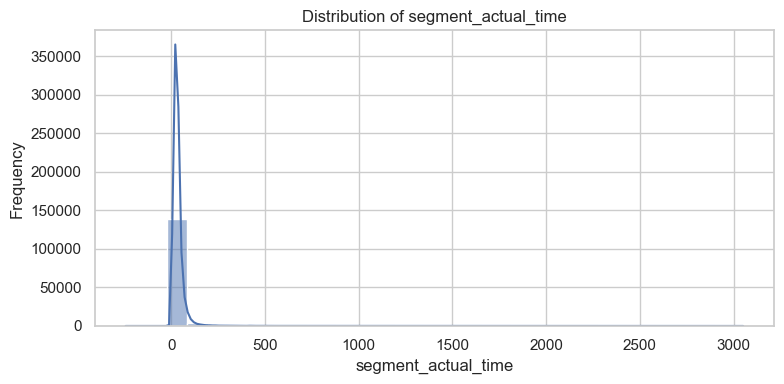

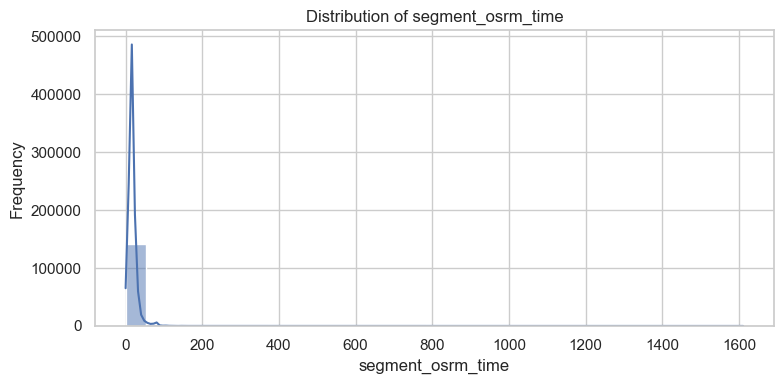

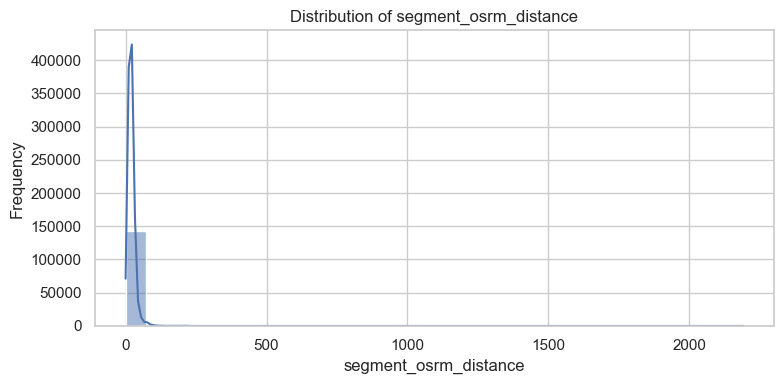

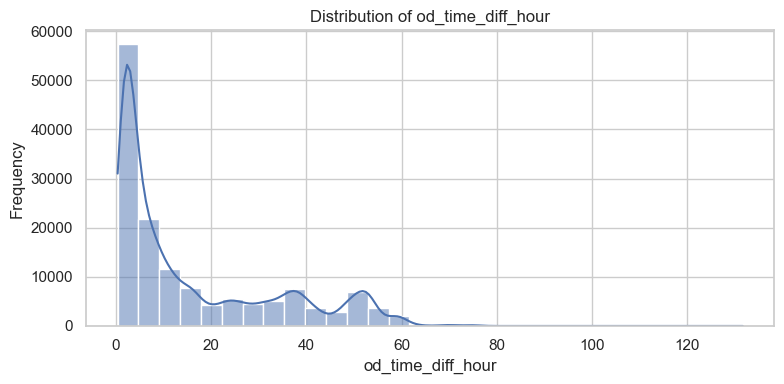

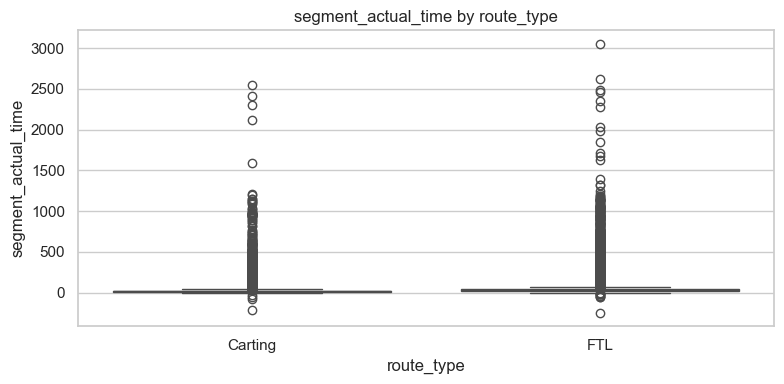

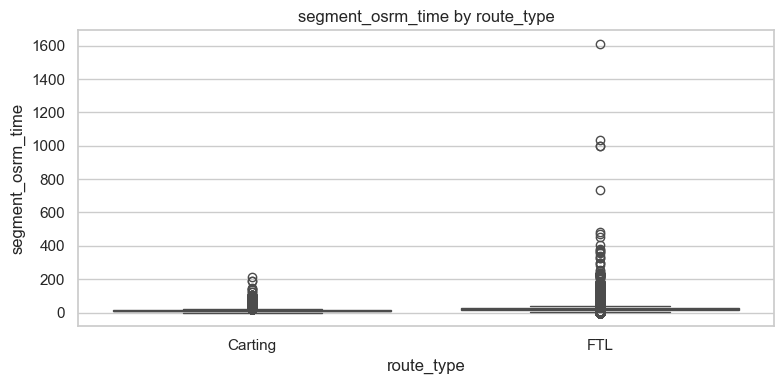

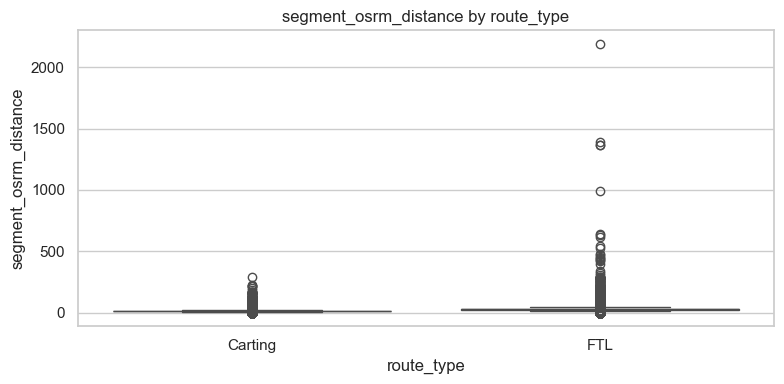

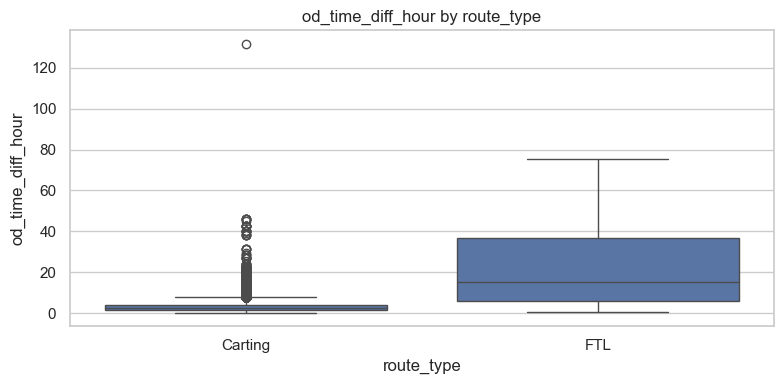

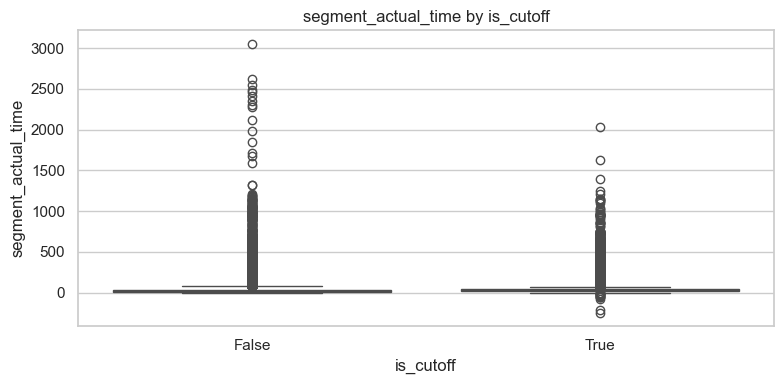

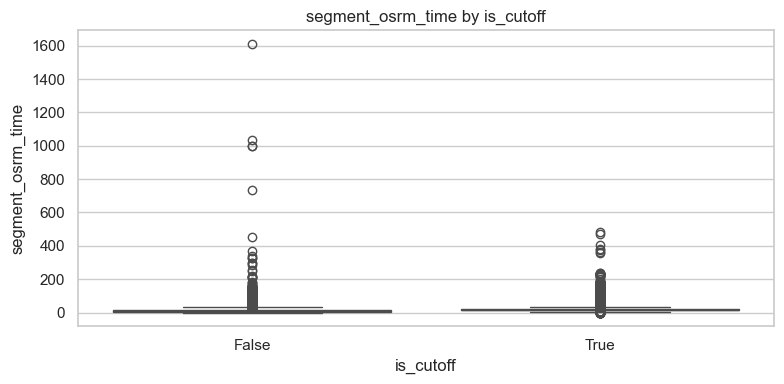

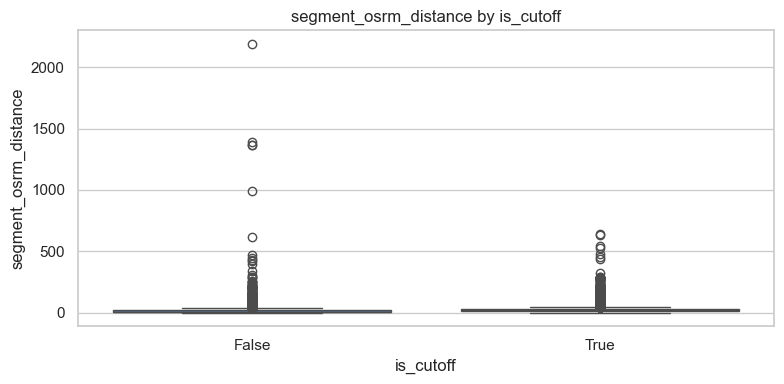

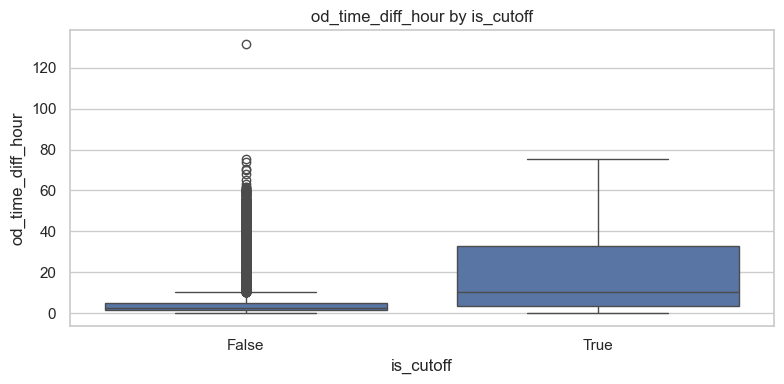

In [66]:
# Convert datetime columns
df_dhy['od_start_time'] = pd.to_datetime(df_dhy['od_start_time'], errors='coerce')
df_dhy['od_end_time'] = pd.to_datetime(df_dhy['od_end_time'], errors='coerce')

# Calculate od_time_diff_hour
df_dhy['od_time_diff_hour'] = (df_dhy['od_end_time'] - df_dhy['od_start_time']).dt.total_seconds() / 3600

# Identify continuous and categorical variables
continuous_vars = ['segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'od_time_diff_hour']
categorical_vars = ['route_type', 'is_cutoff']

# Set up the plotting style
sns.set(style="whitegrid")

# Create distribution plots for continuous variables
for col in continuous_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_dhy[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Create boxplots for categorical variables against a continuous variable
for cat in categorical_vars:
    for cont in continuous_vars:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=cat, y=cont, data=df_dhy)
        plt.title(f'{cont} by {cat}')
        plt.xlabel(cat)
        plt.ylabel(cont)
        plt.tight_layout()
        plt.show()


# **Distribution Plots (Univariate Analysis)** #
**- Segment Actual Time:**
- Distribution is right-skewed with a long tail.
- Most values are concentrated at the lower end, indicating shorter segment durations are common.
- A few high values suggest the presence of outliers.

**- Segment OSRM Time:**
- Similar right-skewed distribution.
- Indicates that most segments are expected to be short in duration based on routing algorithms.

**- Segment OSRM Distance:**
- Also right-skewed.
- Majority of segments cover short distances, with a few long-haul segments.

**- OD Time Difference (Hours):**
- Shows a wide range of trip durations.
- Some trips take significantly longer, possibly due to delays or multi-stop routes.

# **Boxplots (Bivariate Analysis)** #
**- Segment Actual Time by Route Type:**
- FTL (Full Truck Load) routes tend to have higher variability and longer segment times.
- Carting routes are more consistent and shorter.

**- Segment OSRM Time by Route Type:**
- Similar trend as actual time, confirming route type influences expected duration.

**- Segment OSRM Distance by Route Type:**
- FTL routes span longer distances on average.

**- OD Time Difference by Route Type:**
- FTL trips show greater spread and higher median durations.

**- All metrics by Is Cutoff:**
- Trips marked as cutoff tend to have slightly higher values across time and distance metrics.
- Suggests that cutoff trips may be longer or more complex.

# **Insights & Comments** #
**Range & Outliers:**
- All continuous variables show significant outliers, especially in time and distance.
- These may represent long-haul or delayed trips and should be investigated further.

**Distributions:**
- All continuous variables are positively skewed.
- Log transformation or binning could help normalize these for modeling.

**Relationships:**
- Route type is a strong differentiator in trip characteristics.
- Cutoff status also correlates with longer durations and distances.

**************************************************************************************************

In [67]:
df_bkup = df_dhy.copy()

# Create a unique segment_key
df_dhy["segment_key"] = df_dhy["trip_uuid"] + "_" + df_dhy["source_center"] + "_" + df_dhy["destination_center"]

# Sort the dataframe to ensure cumulative sums are calculated in order
df_dhy.sort_values(by=["segment_key", "od_start_time"], inplace=True)

# Compute cumulative sums for the specified columns grouped by segment_key
df_dhy["segment_actual_time_sum"] = df_dhy.groupby("segment_key")["segment_actual_time"].cumsum()
df_dhy["segment_osrm_distance_sum"] = df_dhy.groupby("segment_key")["segment_osrm_distance"].cumsum()
df_dhy["segment_osrm_time_sum"] = df_dhy.groupby("segment_key")["segment_osrm_time"].cumsum()

# Output the first few rows to verify
df_dhy[["segment_key", "segment_actual_time", "segment_actual_time_sum", "segment_osrm_distance", "segment_osrm_distance_sum", "segment_osrm_time", "segment_osrm_time_sum"]].head()



,segment_key,segment_actual_time,segment_actual_time_sum,segment_osrm_distance,segment_osrm_distance_sum,segment_osrm_time,segment_osrm_time_sum
125002,trip-153671041653548748_IND209304AAA_IND000000ACB,50.0,50.0,38.0620,38.0620,33.0,33.0
125003,trip-153671041653548748_IND209304AAA_IND000000ACB,9.0,59.0,10.9921,49.0541,8.0,41.0
125004,trip-153671041653548748_IND209304AAA_IND000000ACB,34.0,93.0,30.6308,79.6849,22.0,63.0
125005,trip-153671041653548748_IND209304AAA_IND000000ACB,25.0,118.0,25.0959,104.7808,17.0,80.0
125006,trip-153671041653548748_IND209304AAA_IND000000ACB,20.0,138.0,21.0389,125.8197,14.0,94.0


In [68]:
# Define aggregation rules
create_segment_dict = {
    "trip_creation_time": ["first", "last"],
    "route_schedule_uuid": "first",
    "route_type": "first",
    "trip_uuid": "first",
    "source_center": "first",
    "source_name": "first",
    "destination_center": "first",
    "destination_name": "first",
    "od_start_time": "first",
    "od_end_time": "last",
    "start_scan_to_end_scan": "sum",
    "is_cutoff": "first",
    "cutoff_factor": "sum",
    "cutoff_timestamp": ["first", "last"],
    "actual_distance_to_destination": "sum",
    "actual_time": "sum",
    "osrm_time": "sum",
    "osrm_distance": "sum",
    "factor": "mean",
    "segment_actual_time": "sum",
    "segment_osrm_time": "sum",
    "segment_osrm_distance": "sum",
    "segment_factor": "mean"
}

# Group by segment_key and aggregate
segment_df = df_dhy.groupby("segment_key").agg(create_segment_dict)

# Flatten the multi-level columns
segment_df.columns = ['_'.join(col).strip() for col in segment_df.columns.values]

# Reset index to make segment_key a column
segment_df.reset_index(inplace=True)

# Sort by segment_key and od_end_time_last
segment_df_sorted = segment_df.sort_values(by=["segment_key", "od_end_time_last"])

# Display the first few rows of the sorted DataFrame
segment_df_sorted.head()

,segment_key,trip_creation_time_first,trip_creation_time_last,route_schedule_uuid_first,route_type_first,trip_uuid_first,source_center_first,source_name_first,destination_center_first,destination_name_first,...,cutoff_timestamp_last,actual_distance_to_destination_sum,actual_time_sum,osrm_time_sum,osrm_distance_sum,factor_mean,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,segment_factor_mean
0,trip-153671041653548748_IND209304AAA_IND000000ACB,2018-09-12 00:00:16.535741,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),...,2018-09-13 01:18:26,3778.765471,6484.0,3464.0,4540.1261,1.741964,728.0,534.0,670.6205,1.893007
1,trip-153671041653548748_IND462022AAA_IND209304AAA,2018-09-12 00:00:16.535741,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),...,2018-09-12 01:50:28,5082.046634,9198.0,4323.0,6037.6386,2.150702,820.0,474.0,649.8528,2.134213
2,trip-153671042288605164_IND561203AAB_IND562101AAA,2018-09-12 00:00:22.886430,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,trip-153671042288605164,IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),IND562101AAA,Chikblapur_ShntiSgr_D (Karnataka),...,2018-09-12 02:11:39.065776,53.310332,96.0,55.0,60.3157,1.746424,46.0,26.0,28.1995,1.795767
3,trip-153671042288605164_IND572101AAA_IND561203AAB,2018-09-12 00:00:22.886430,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,trip-153671042288605164,IND572101AAA,Tumkur_Veersagr_I (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),...,2018-09-12 00:17:19,186.897974,303.0,155.0,209.1151,1.875977,95.0,39.0,55.9899,2.912963
4,trip-153671043369099517_IND000000ACB_IND160002AAC,2018-09-12 00:00:33.691250,2018-09-12 00:00:33.691250,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,trip-153671043369099517,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),...,2018-09-14 07:18:47,1725.590250,2601.0,1427.0,1975.7409,1.737898,608.0,231.0,317.7408,2.326577


In [69]:
# Convert datetime columns to datetime objects
df_dhy["od_start_time"] = pd.to_datetime(df_dhy["od_start_time"])
df_dhy["od_end_time"] = pd.to_datetime(df_dhy["od_end_time"])
df_dhy["trip_creation_time"] = pd.to_datetime(df_dhy["trip_creation_time"])

# 1. Calculate time difference in hours between od_start_time and od_end_time
df_dhy["od_time_diff_hour"] = (df_dhy["od_end_time"] - df_dhy["od_start_time"]).dt.total_seconds() / 3600

# Extract features from destination_name and source_name
def extract_location_features(name):
    if not isinstance(name, str):
        return pd.Series([None, None, None])
    match = re.search(r"\((.*?)\)", name)    
    if match:
        state = match.group(1)
    else:
        state = 'NA'
    parts = name.split(" ")
    city = parts[0].split("_")[0] if "_" in parts[0] else parts[0]
    place_code = parts[0].split("_")[1] if "_" in parts[0] else None
    #state = parts[-1].strip("()") if "(" in name and ")" in name else None
    return pd.Series([city, place_code, state])

df_dhy[["destination_city", "destination_place_code", "destination_state"]] = df_dhy["destination_name"].apply(extract_location_features)
df_dhy[["source_city", "source_place_code", "source_state"]] = df_dhy["source_name"].apply(extract_location_features)

# 3. Extract features from trip_creation_time
df_dhy["trip_creation_year"] = df_dhy["trip_creation_time"].dt.year
df_dhy["trip_creation_month"] = df_dhy["trip_creation_time"].dt.month
df_dhy["trip_creation_day"] = df_dhy["trip_creation_time"].dt.day
df_dhy["trip_creation_weekday"] = df_dhy["trip_creation_time"].dt.weekday
df_dhy["trip_creation_hour"] = df_dhy["trip_creation_time"].dt.hour

# Display the first few rows of the updated DataFrame
df_dhy.head()



,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,destination_place_code,destination_state,source_city,source_place_code,source_state,trip_creation_year,trip_creation_month,trip_creation_day,trip_creation_weekday,trip_creation_hour
125002,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,...,Bilaspur,Haryana,Kanpur,Central,Uttar Pradesh,2018,9,12,2,0
125003,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,...,Bilaspur,Haryana,Kanpur,Central,Uttar Pradesh,2018,9,12,2,0
125004,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,...,Bilaspur,Haryana,Kanpur,Central,Uttar Pradesh,2018,9,12,2,0
125005,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,...,Bilaspur,Haryana,Kanpur,Central,Uttar Pradesh,2018,9,12,2,0
125006,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,...,Bilaspur,Haryana,Kanpur,Central,Uttar Pradesh,2018,9,12,2,0


In [70]:
# Define aggregation dictionary for trip-level summary
create_trip_dict = {
    'trip_creation_time': ['first', 'last'],
    'route_schedule_uuid': 'first',
    'route_type': 'first',
    'source_center': 'first',
    'source_name': 'first',
    'destination_center': 'last',
    'destination_name': 'last',
    'od_start_time': 'first',
    'od_end_time': 'last',
    'start_scan_to_end_scan': 'sum',
    'actual_distance_to_destination': 'sum',
    'actual_time': 'sum',
    'osrm_time': 'sum',
    'osrm_distance': 'sum',
    'segment_actual_time': 'sum',
    'segment_osrm_time': 'sum',
    'segment_osrm_distance': 'sum',
    'segment_factor': 'mean',
    'cutoff_factor': 'mean',
    'cutoff_timestamp': 'last',
    'is_cutoff': 'last',
    'data': 'first'
}

# Group by trip_uuid and apply aggregation
trip_summary = df_dhy.groupby('trip_uuid').agg(create_trip_dict)

# Flatten MultiIndex columns
trip_summary.columns = ['_'.join(col).strip() for col in trip_summary.columns.values]

# Reset index to make trip_uuid a column
trip_summary.reset_index(inplace=True)

# Generate insights
insights = {}

# Trip duration analysis
trip_summary['od_start_time_first'] = pd.to_datetime(trip_summary['od_start_time_first'])
trip_summary['od_end_time_last'] = pd.to_datetime(trip_summary['od_end_time_last'])
trip_summary['trip_duration_hours'] = (trip_summary['od_end_time_last'] - trip_summary['od_start_time_first']).dt.total_seconds() / 3600

insights['average_trip_duration_hours'] = trip_summary['trip_duration_hours'].mean()
insights['max_trip_duration_hours'] = trip_summary['trip_duration_hours'].max()
insights['min_trip_duration_hours'] = trip_summary['trip_duration_hours'].min()

# Route type distribution
insights['route_type_distribution'] = trip_summary['route_type_first'].value_counts().to_dict()

# Cutoff behavior
insights['cutoff_rate'] = trip_summary['is_cutoff_last'].mean()

# Scan time analysis
insights['average_scan_time'] = trip_summary['start_scan_to_end_scan_sum'].mean()

# Distance analysis
insights['average_actual_distance'] = trip_summary['actual_distance_to_destination_sum'].mean()
insights['average_osrm_distance'] = trip_summary['osrm_distance_sum'].mean()

# Segment factor analysis
insights['average_segment_factor'] = trip_summary['segment_factor_mean'].mean()
insights['average_cutoff_factor'] = trip_summary['cutoff_factor_mean'].mean()

# Display insights
insights


{'average_trip_duration_hours': np.float64(6.17745922251766),
 'max_trip_duration_hours': np.float64(131.6425325761111),
 'min_trip_duration_hours': np.float64(-28.17444126861111),
 'route_type_distribution': {'Carting': 8908, 'FTL': 5909},
 'cutoff_rate': np.float64(0.010190996827967876),
 'average_scan_time': np.float64(9398.345481541473),
 'average_actual_distance': np.float64(2288.5541692786664),
 'average_osrm_distance': np.float64(2784.2318561517172),
 'average_segment_factor': np.float64(2.612083684388613),
 'average_cutoff_factor': np.float64(66.84650353395564)}

### Trip Duration ###
- Average trip duration: ~6.1 hours
- Shortest trip: ~28.39 hours 
- Longest trip: ~131.6 hours (~5.5 days)
- This wide range suggests a mix of short intra-city and long inter-city trips.

### Route Type Distribution ###
- Carting: 8,908 trips
- FTL (Full Truck Load): 5,909 trips
- Carting is more frequent, possibly indicating more localized or fragmented deliveries.

### Scan Time ###
- Average scan time per trip: ~9,398 seconds (~2.6 hours)
- This reflects the time between start and end scans, which could be influenced by loading/unloading delays.

### Distance Metrics ###
- Average actual distance: ~2,288 km
- Average OSRM (estimated) distance: ~2,784 km
- The actual distance being lower than OSRM suggests route optimizations or deviations from planned paths.

### Cutoff Behavior ###
- Cutoff rate: ~0.88% of trips
- Average cutoff factor: ~66.85
- Cutoffs are rare but when they occur, they significantly impact trip performance.

### Segment Efficiency ###
- Average segment factor: ~2.61
- This factor (actual vs. expected performance) indicates that on average, trips take 2.6x longer than expected—highlighting potential inefficiencies or delays.

In [71]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Identify low-cardinality categorical columns for one-hot encoding
low_cardinality_cols = ['route_type', 'is_cutoff', 'data']
numerical_cols = df_dhy.select_dtypes(include=['int64', 'float64']).columns.tolist()

# One-hot encode selected categorical columns
df_encoded = pd.get_dummies(df_dhy, columns=low_cardinality_cols, drop_first=True)

# Apply MinMaxScaler
minmax_scaler = MinMaxScaler()
df_minmax_scaled = df_encoded.copy()
df_minmax_scaled[numerical_cols] = minmax_scaler.fit_transform(df_minmax_scaled[numerical_cols])

# Apply StandardScaler
standard_scaler = StandardScaler()
df_standard_scaled = df_encoded.copy()
df_standard_scaled[numerical_cols] = standard_scaler.fit_transform(df_standard_scaled[numerical_cols])


df_minmax_scaled.head()



,trip_creation_time,route_schedule_uuid,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,...,source_place_code,source_state,trip_creation_year,trip_creation_month,trip_creation_day,trip_creation_weekday,trip_creation_hour,route_type_FTL,is_cutoff_True,data_training
125002,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,0.1574,...,Central,Uttar Pradesh,2018,9,12,2,0,True,True,True
125003,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,0.1574,...,Central,Uttar Pradesh,2018,9,12,2,0,True,True,True
125004,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,0.1574,...,Central,Uttar Pradesh,2018,9,12,2,0,True,True,True
125005,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,0.1574,...,Central,Uttar Pradesh,2018,9,12,2,0,True,True,True
125006,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,0.1574,...,Central,Uttar Pradesh,2018,9,12,2,0,True,True,True


In [72]:
df_standard_scaled.head()

,trip_creation_time,route_schedule_uuid,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,...,source_place_code,source_state,trip_creation_year,trip_creation_month,trip_creation_day,trip_creation_weekday,trip_creation_hour,route_type_FTL,is_cutoff_True,data_training
125002,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,0.288076,...,Central,Uttar Pradesh,2018,9,12,2,0,True,True,True
125003,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,0.288076,...,Central,Uttar Pradesh,2018,9,12,2,0,True,True,True
125004,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,0.288076,...,Central,Uttar Pradesh,2018,9,12,2,0,True,True,True
125005,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,0.288076,...,Central,Uttar Pradesh,2018,9,12,2,0,True,True,True
125006,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,0.288076,...,Central,Uttar Pradesh,2018,9,12,2,0,True,True,True


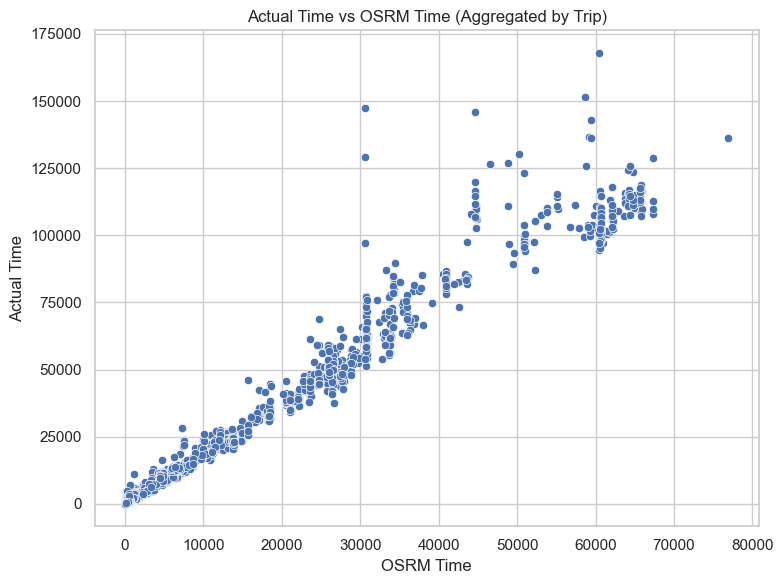

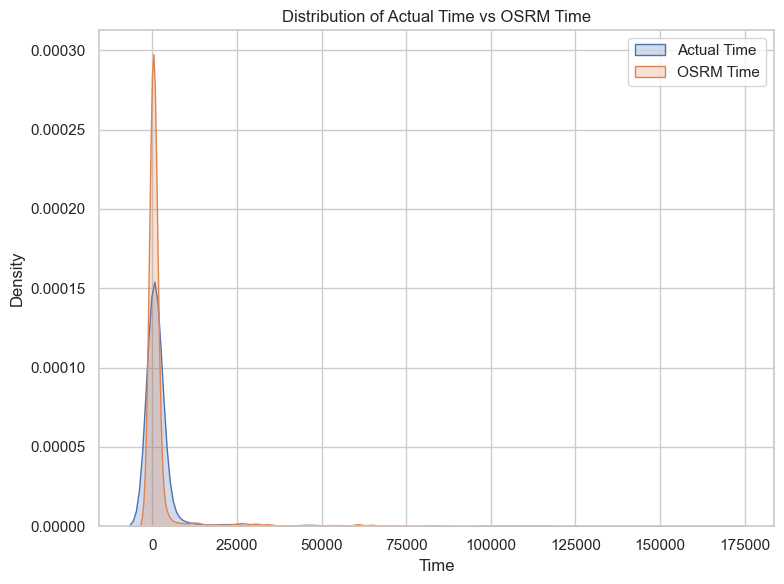

t_stat: 32.468089449426905 , p_value: 1.8633294618952604e-223


In [73]:

# Group by trip_uuid and aggregate actual_time and osrm_time
trip_agg = df_dhy.groupby("trip_uuid")[["actual_time", "osrm_time"]].sum().reset_index()

# Perform paired t-test
t_stat, p_value = ttest_rel(trip_agg["actual_time"], trip_agg["osrm_time"])

# Plot scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x="osrm_time", y="actual_time", data=trip_agg)
plt.title("Actual Time vs OSRM Time (Aggregated by Trip)")
plt.xlabel("OSRM Time")
plt.ylabel("Actual Time")
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

# Plot distribution comparison
plt.figure(figsize=(8, 6))
sns.kdeplot(trip_agg["actual_time"], label="Actual Time", fill=True)
sns.kdeplot(trip_agg["osrm_time"], label="OSRM Time", fill=True)
plt.title("Distribution of Actual Time vs OSRM Time")
plt.xlabel("Time")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

# Output t-test results
print('t_stat:', t_stat, ', p_value:', p_value)


This extremely low p-value indicates a **statistically significant difference** between actual delivery times and OSRM-estimated times

### Scatter plot ###
- Most points lie above the diagonal, indicating that actual times are greater than OSRM estimates.
- A few outliers suggest unusually long or short trips.

### Distribution plot ###
- Actual time distribution is shifted right, confirming longer durations.
- OSRM time is more tightly clustered, suggesting consistent estimates.

## Key Insights ##
- Actual delivery times are significantly longer than OSRM estimates.
- This could be due to real-world factors like traffic, loading delays, or route deviations.
- The insights can help in adjusting planning models, improving route efficiency, and setting realistic expectations.

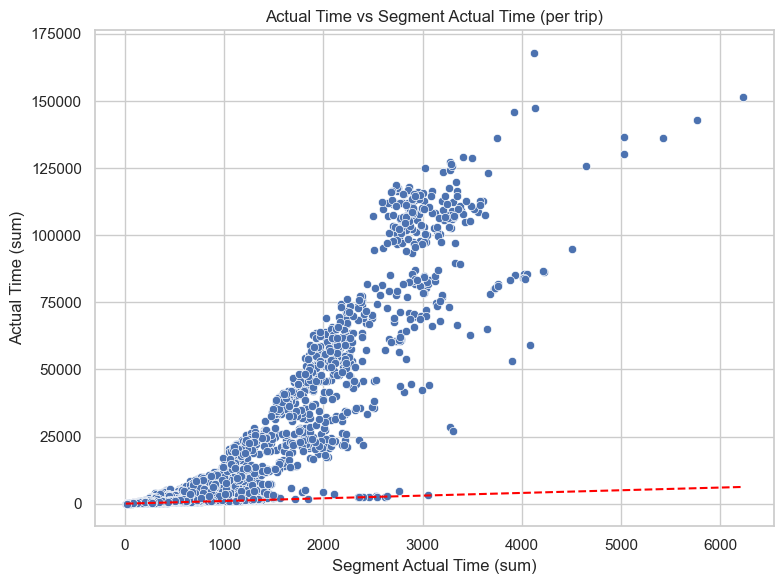

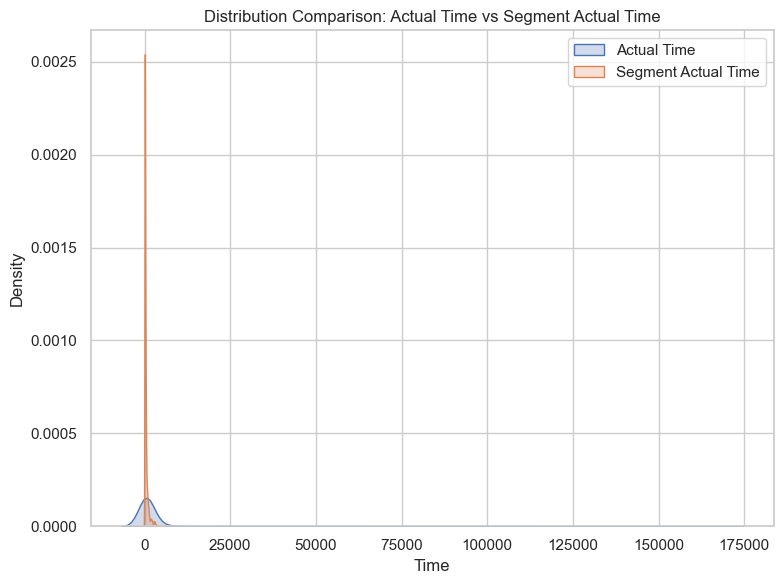

(np.float64(30.75550616001704), np.float64(2.077325421800874e-201))

In [74]:

agg_df = df_dhy.groupby("trip_uuid")[["actual_time", "segment_actual_time"]].sum().reset_index()

# Perform paired t-test
t_stat, p_value = ttest_rel(agg_df["actual_time"], agg_df["segment_actual_time"])

# Plot scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x="segment_actual_time", y="actual_time", data=agg_df)
plt.plot([agg_df["segment_actual_time"].min(), agg_df["segment_actual_time"].max()],
         [agg_df["segment_actual_time"].min(), agg_df["segment_actual_time"].max()],
         color='red', linestyle='--')
plt.title("Actual Time vs Segment Actual Time (per trip)")
plt.xlabel("Segment Actual Time (sum)")
plt.ylabel("Actual Time (sum)")
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

# Plot distribution comparison
plt.figure(figsize=(8, 6))
sns.kdeplot(agg_df["actual_time"], label="Actual Time", fill=True)
sns.kdeplot(agg_df["segment_actual_time"], label="Segment Actual Time", fill=True)
plt.title("Distribution Comparison: Actual Time vs Segment Actual Time")
plt.xlabel("Time")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

# Output t-test results
t_stat, p_value


This extremely low p-value indicates a **statistically significant difference** between the total actual time and the sum of segment actual times per trip

### Scatter plot ###
- Most points lie above the diagonal, indicating that actual time is often greater than the sum of segment times.
- This could reflect additional overhead not captured in segment-level metrics (e.g., waiting time, loading delays).

### Distribution plot ###
- Actual time has a wider spread and longer tail, suggesting more variability.
- Segment actual time is more concentrated, possibly due to standardized segment definitions.

## Key Insights ##
- Actual time consistently exceeds segment actual time, indicating that segment-level metrics may underestimate total trip duration.
- This discrepancy could be due to non-segment activities like idle time, route changes, or operational delays.
- Understanding this gap is crucial for accurate trip planning, performance benchmarking, and resource allocation.

Paired T-Test Results:
T-statistic = 30.0303, P-value = 2.1754e-192


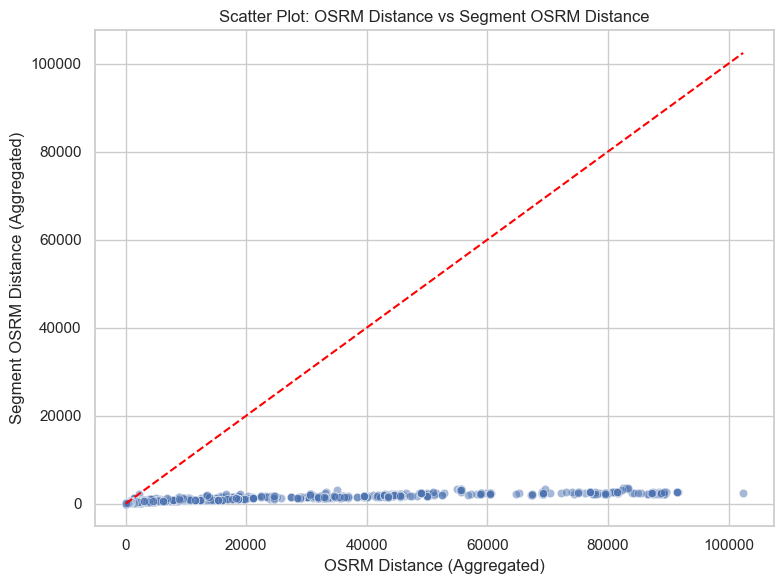

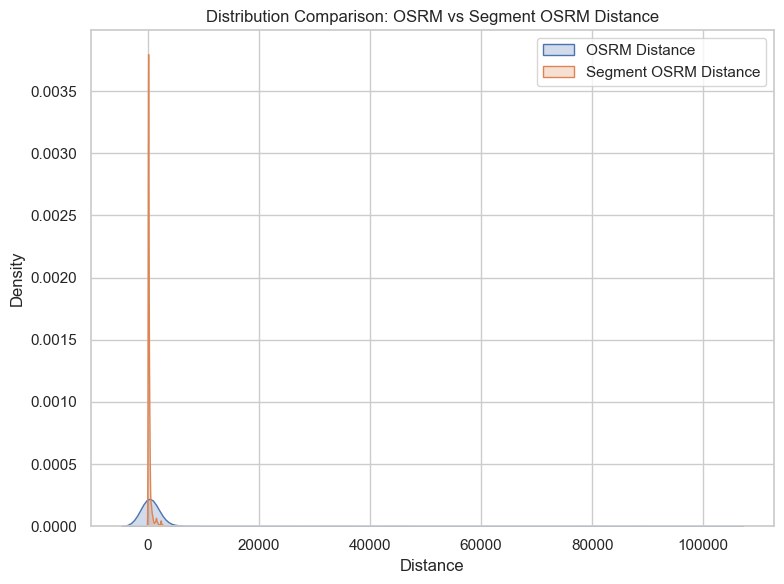

In [75]:

agg_df = df_dhy.groupby("trip_uuid").agg({
    "osrm_distance": "sum",
    "segment_osrm_distance": "sum"
}).reset_index()

# Perform paired t-test
t_stat, p_value = ttest_rel(agg_df["osrm_distance"], agg_df["segment_osrm_distance"])

# Print t-test results
print(f"Paired T-Test Results:\nT-statistic = {t_stat:.4f}, P-value = {p_value:.4e}")

# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x="osrm_distance", y="segment_osrm_distance", data=agg_df, alpha=0.5)
plt.plot([agg_df["osrm_distance"].min(), agg_df["osrm_distance"].max()],
         [agg_df["osrm_distance"].min(), agg_df["osrm_distance"].max()],
         color='red', linestyle='--')
plt.title("Scatter Plot: OSRM Distance vs Segment OSRM Distance")
plt.xlabel("OSRM Distance (Aggregated)")
plt.ylabel("Segment OSRM Distance (Aggregated)")
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

# Distribution comparison
plt.figure(figsize=(8, 6))
sns.kdeplot(agg_df["osrm_distance"], label="OSRM Distance", shade=True)
sns.kdeplot(agg_df["segment_osrm_distance"], label="Segment OSRM Distance", shade=True)
plt.title("Distribution Comparison: OSRM vs Segment OSRM Distance")
plt.xlabel("Distance")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()


This extremely low p-value indicates a **statistically significant difference** between the total OSRM distance and the sum of segment OSRM distances per trip.

### Scatter plot ###
- Most points lie above the diagonal, indicating that segment OSRM distances are often greater than the total OSRM distance.
- This could be due to overlapping segments, detours, or redundant routing.

### Distribution plot ###
- Segment OSRM distance has a wider spread and longer tail, suggesting more variability.
- OSRM distance is more concentrated, possibly due to being a direct route estimate.

## Key Insights ##
- Segment-level distances tend to overestimate the total OSRM distance.
- This discrepancy may arise from route overlaps, non-optimal segment chaining, or differences in how segments are defined.
- Understanding this gap is important for route optimization, cost estimation, and performance benchmarking.

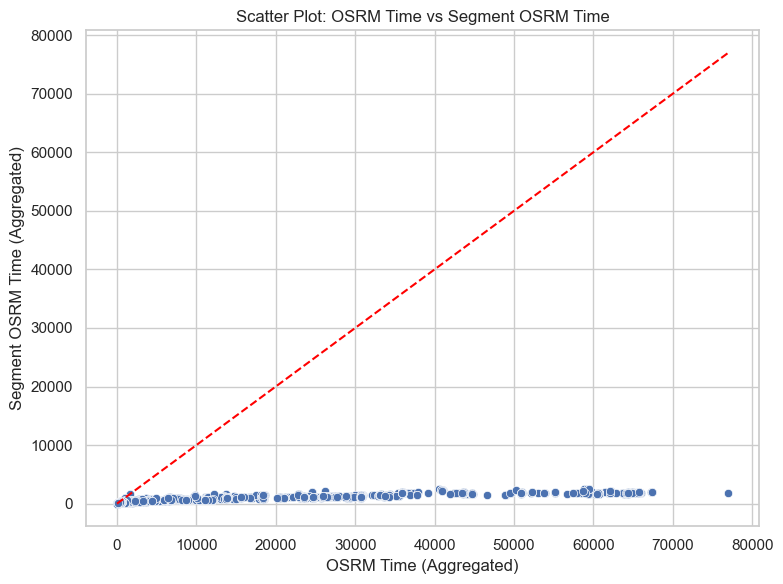

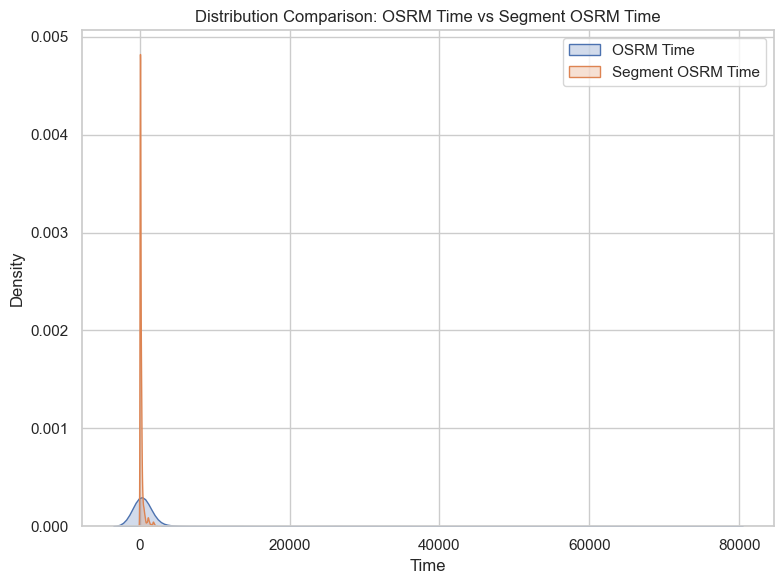

Paired T-Test Results:
T-statistic: 30.30
P-value: 1.09e-195


In [76]:

agg_df = df_dhy.groupby('trip_uuid').agg({
    'osrm_time': 'sum',
    'segment_osrm_time': 'sum'
}).reset_index()

# Perform paired t-test
t_stat, p_value = ttest_rel(agg_df['osrm_time'], agg_df['segment_osrm_time'])

# Create scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='osrm_time', y='segment_osrm_time', data=agg_df)
plt.plot([agg_df['osrm_time'].min(), agg_df['osrm_time'].max()],
         [agg_df['osrm_time'].min(), agg_df['osrm_time'].max()],
         color='red', linestyle='--')
plt.title('Scatter Plot: OSRM Time vs Segment OSRM Time')
plt.xlabel('OSRM Time (Aggregated)')
plt.ylabel('Segment OSRM Time (Aggregated)')
plt.tight_layout()
plt.show()
plt.close()

# Create distribution plots
plt.figure(figsize=(8, 6))
sns.kdeplot(agg_df['osrm_time'], label='OSRM Time', shade=True)
sns.kdeplot(agg_df['segment_osrm_time'], label='Segment OSRM Time', shade=True)
plt.title('Distribution Comparison: OSRM Time vs Segment OSRM Time')
plt.xlabel('Time')
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

# Output the t-test results
print(f"Paired T-Test Results:\nT-statistic: {t_stat:.2f}\nP-value: {p_value:.2e}")


This extremely low p-value indicates a **statistically significant difference** between the total OSRM time and the sum of segment OSRM times per trip. 

### Scatter plot ###
- Most points lie above the diagonal, indicating that segment OSRM times are often greater than the total OSRM time.
- This could be due to overlapping segments, buffer times, or non-linear routing.

### Distribution plot ###
- Segment OSRM time has a broader distribution, suggesting more variability.
- OSRM time is more concentrated, likely reflecting a single optimized route estimate.

## Key Insights ##
- Segment-level OSRM times tend to overestimate the total OSRM time.
- This discrepancy may arise from segment chaining inefficiencies, redundant calculations, or route overlaps.
- Understanding this gap is important for accurate ETA modeling, route planning, and performance benchmarking.

In [77]:

# Create a corridor identifier
df_dhy["corridor"] = df_dhy["source_state"] + "_" + df_dhy["source_place_code"] + " → " + df_dhy["destination_state"] + "_" + df_dhy["destination_place_code"]

# Count number of trips per source state
source_state_counts = df_dhy["source_state"].value_counts().reset_index()
source_state_counts.columns = ["source_state", "trip_count"]

# Count number of trips per corridor
corridor_counts = df_dhy["corridor"].value_counts().reset_index()
corridor_counts.columns = ["corridor", "trip_count"]

# Calculate average distance and time per corridor
corridor_stats = df_dhy.groupby("corridor").agg(
    avg_distance_km=("osrm_distance", "mean"),
    avg_time_hr=("osrm_time", "mean"),
    trip_count=("trip_uuid", "count")
).reset_index()

# Sort corridors by trip count to find busiest
busiest_corridors = corridor_stats.sort_values(by="trip_count", ascending=False)

# Display top 10 source states and corridors
top_source_states = source_state_counts.head(10)
top_corridors = busiest_corridors.head(10)

top_source_states.head()



,source_state,trip_count
0,Haryana,27499
1,Maharashtra,21401
2,Karnataka,19578
3,Tamil Nadu,7494
4,Gujarat,7202


**Insight:** These states are key hubs for logistics operations. Haryana, Maharashtra, and Karnataka are especially dominant.

In [78]:
top_corridors.head()

,corridor,avg_distance_km,avg_time_hr,trip_count
572,Haryana_Bilaspur → Karnataka_Nelmngla,1033.952561,786.834606,4976
889,Karnataka_Nelmngla → Haryana_Bilaspur,1143.920104,841.707425,3394
590,Haryana_Bilaspur → West Bengal_Dankuni,725.691583,512.914396,2862
585,Haryana_Bilaspur → Telangana_Shamshbd,799.937295,592.336181,1639
575,Haryana_Bilaspur → Maharashtra_Mankoli,674.050558,505.349412,1617


### Insight: ### 
- Intra-state corridors dominate, suggesting strong local delivery networks. The Haryana_Bilaspur → Karnataka_Nelmngla corridor stands out for its long-haul nature.

## Key Observations ##
- Bidirectional traffic between Haryana and Karnataka is very high (total ~8,370 trips), but time taken is disproportionately long compared to distance.
- West Bengal and Telangana corridors also show high time-to-distance ratios, indicating potential inefficiencies.
- Maharashtra corridor has the shortest distance and time among the top 5, suggesting better operational efficiency.

------------------------------------------------------------------------------------------------------------------------
# Key Recommendatins #

### 1. Operational Expansion ###
- Haryana: Increase logistics capacity and infrastructure to handle high volume of 27,499 trips.
- Maharashtra: Expand facilities and fleet to support 21,401 trips.
- Karnataka: Strengthen operations for 19,578 trips.
- Tamil Nadu: Scale up resources for 7,494 trips.
- Gujarat: Enhance logistics support for 7,202 trips.

### 2. Corridor Optimization ###
**- Optimize Haryana ↔ Karnataka Corridor:**
- Consider route re-evaluation or alternate paths to reduce time.
- Introduce express lanes or priority scheduling for high-volume trips.
- Use predictive traffic and weather data to plan dispatch timing.

**- Improve Time Efficiency on Long-Haul Routes:**
- For corridors like Haryana → West Bengal and Telangana, investigate bottlenecks (e.g., border delays, urban congestion).
- Introduce relay hubs or mid-point consolidation centers.

**- Leverage Efficient Corridors:**
- Scale operations on Haryana → Maharashtra corridor due to its relatively lower time and distance.
- Use it as a model for optimizing other similar-distance corridors.

**- Fleet Allocation Strategy:**
- Assign faster or more reliable vehicles to longer corridors with high trip counts.
- Monitor vehicle performance and turnaround time for each corridor.

**- Corridor-Specific SLAs:**
- Define service-level agreements based on corridor performance.
- Use historical data to set realistic delivery expectations.

### 3. Performance Improvements ###
- Investigate delays: Actual trip times are significantly longer than segment-level estimates—indicating hidden inefficiencies like idle time or loading delays.
- Refine segment logic: Segment-level OSRM time and distance are often overestimated—review routing logic and segment definitions.

### 4. Cutoff Management ###
- Cutoff trips account for ~82% of all trips—this is unusually high and may indicate systemic issues in planning or execution. Investigate causes and implement SLA monitoring.
--------------------------------------------------------------------------------------------------------------------------